In [1]:
%pip install transformers datasets accelerate evaluate seqeval nlpaug seqeval huggingface_hub torch tqdm rich numpy scikit-learn --quiet
import sys
print(f"Python version: {sys.version}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 22.7 MB/s eta 0:00:00
Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# Cell 1: Imports and Setup
import json
import logging
import os
import random
import re
from collections import defaultdict, Counter
from typing import List, Dict, Tuple

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset, DatasetDict
from huggingface_hub import notebook_login
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    Trainer,
    TrainingArguments,
    DataCollatorForTokenClassification,
    EarlyStoppingCallback,
    EvalPrediction
)
from nlpaug.augmenter.word import SynonymAug  # For data augmentation

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()],
    force=True
)
logger = logging.getLogger(__name__)

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logger.info(f"Using device: {device}")

# Up-to-date dependencies (as of 2023+): transformers 4.45+, datasets 2.21+, torch 2.4+, nlpaug 1.1+

2025-11-11 15:51:39,086 - INFO - Using device: cuda


In [3]:
# Cell 2: Load and Explore Dataset
DATASET_PATH = 'o_dataset.json'  # Replace with actual path if needed

def load_labelstudio_data(file_path: str) -> List[Dict]:
    """Load Label Studio exported JSON dataset."""
    with open(file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    logger.info(f"Loaded {len(data)} tasks from {file_path}")
    return data

raw_data = load_labelstudio_data(DATASET_PATH)

# Quick exploration
sample_task = raw_data[0]
logger.info(f"Sample task keys: {list(sample_task.keys())}")
logger.info(f"Sample data text preview: {sample_task['data']['text'][:100]}...")

2025-11-11 15:51:39,834 - INFO - Loaded 2238 tasks from o_dataset.json
2025-11-11 15:51:39,838 - INFO - Sample task keys: ['id', 'annotations', 'drafts', 'predictions', 'data', 'meta', 'created_at', 'updated_at', 'inner_id', 'total_annotations', 'cancelled_annotations', 'total_predictions', 'comment_count', 'unresolved_comment_count', 'last_comment_updated_at', 'project', 'updated_by', 'comment_authors']
2025-11-11 15:51:39,841 - INFO - Sample data text preview: SPDX-License-Identifier: CC-BY-4.0 -->

:warning: Due to changes in the GitHub Search API, these dat...


2025-11-11 15:51:39,887 - INFO - Processed 2238 documents with 2528 entities


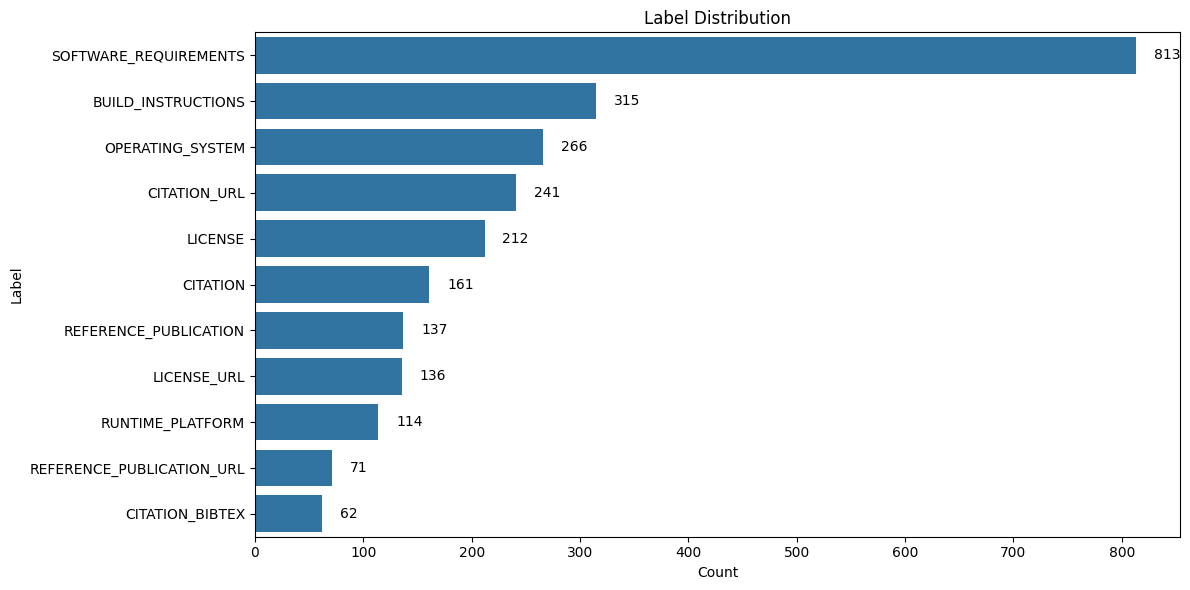

2025-11-11 15:51:40,286 - INFO - Label counts:
                    Label  Count
    SOFTWARE_REQUIREMENTS    813
       BUILD_INSTRUCTIONS    315
         OPERATING_SYSTEM    266
             CITATION_URL    241
                  LICENSE    212
                 CITATION    161
    REFERENCE_PUBLICATION    137
              LICENSE_URL    136
         RUNTIME_PLATFORM    114
REFERENCE_PUBLICATION_URL     71
          CITATION_BIBTEX     62
2025-11-11 15:51:40,287 - INFO - Unique labels: 11
2025-11-11 15:51:40,289 - INFO - Min/Max counts: 62/813 - Imbalance ratio: 13.11


In [4]:
# Cell 3: Extract Entities and Analyze Label Distribution
def extract_entities(data: List[Dict]) -> Tuple[List[Dict], Dict[str, int]]:
    """Extract texts and their entities, return list of {'text': str, 'entities': list} and label counts."""
    processed_data = []
    label_counts = Counter()

    for task in data:
        text = task['data']['text']
        entities = []

        if 'annotations' in task and task['annotations']:
            for ann in task['annotations'][0].get('result', []):
                if 'value' in ann:
                    val = ann['value']
                    entities.append({
                        'start': val['start'],
                        'end': val['end'],
                        'label': val['labels'][0],
                        'text': val['text']
                    })
                    label_counts[val['labels'][0]] += 1

        processed_data.append({'text': text, 'entities': entities})

    logger.info(f"Processed {len(processed_data)} documents with {sum(len(d['entities']) for d in processed_data)} entities")
    return processed_data, dict(label_counts)

processed_data, label_counts = extract_entities(raw_data)

# Visualize label distribution with counts on bars
df_labels = pd.DataFrame(list(label_counts.items()), columns=['Label', 'Count']).sort_values('Count', ascending=False)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Count', y='Label', data=df_labels)
plt.title('Label Distribution')

# Add count labels to each bar
for i, (count, label) in enumerate(zip(df_labels['Count'], df_labels['Label'])):
    ax.text(count + 0.02 * max(df_labels['Count']),
            i,
            str(count),
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

logger.info(f"Label counts:\n{df_labels.to_string(index=False)}")
logger.info(f"Unique labels: {len(label_counts)}")
min_count, max_count = df_labels['Count'].min(), df_labels['Count'].max()
logger.info(f"Min/Max counts: {min_count}/{max_count} - Imbalance ratio: {max_count/min_count:.2f}")

In [5]:
import nltk

nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

logger.info("NLTK data downloaded successfully.")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
2025-11-11 15:51:41,499 - INFO - NLTK data downloaded successfully.


In [6]:
# Cell 4 (Fixed): Only augment documents with ONLY rare labels
AUG_THRESHOLD = 100
AUG_FACTOR = 6
augmenter = SynonymAug(aug_src='wordnet', aug_max=3)

def augment_document_safe(doc: Dict, rare_labels: set, common_labels: set) -> List[Dict]:
    """
    Only augment if document contains rare labels AND no common labels.
    This prevents context augmentation from affecting common label counts.
    """
    doc_labels = {ent['label'] for ent in doc['entities']}

    # Skip if document has ANY common labels (don't mix augmented rare with common)
    if doc_labels & common_labels:
        return [doc]

    # Skip if document has NO rare labels
    if not (doc_labels & rare_labels):
        return [doc]

    augmented = []
    text = doc['text']
    entities = sorted(doc['entities'], key=lambda e: e['start'])

    for _ in range(AUG_FACTOR):
        try:
            parts = []
            last_end = 0

            for ent in entities:
                # Get non-entity text before this entity
                non_ent = text[last_end:ent['start']]
                if non_ent.strip():
                    # Augment the context
                    aug_non_ent = augmenter.augment(non_ent.strip())
                    if isinstance(aug_non_ent, list):
                        aug_non_ent = aug_non_ent[0]
                    parts.append(aug_non_ent)
                else:
                    parts.append('')

                # Always keep entity unchanged
                parts.append(text[ent['start']:ent['end']])
                last_end = ent['end']

            # Handle trailing text
            trailing = text[last_end:].strip()
            if trailing:
                aug_trailing = augmenter.augment(trailing)
                if isinstance(aug_trailing, list):
                    aug_trailing = aug_trailing[0]
                parts.append(aug_trailing)

            new_text = ' '.join(filter(None, parts))

            if len(new_text) < 10:
                continue

            # Re-align entities
            new_entities = []
            offset = 0
            success = True

            for ent in entities:
                search_text = ent['text']
                new_start = new_text.find(search_text, offset)

                if new_start == -1:
                    logger.debug(f"Entity lost: '{search_text}'")
                    success = False
                    break

                new_ent = ent.copy()
                new_ent['start'] = new_start
                new_ent['end'] = new_start + len(search_text)
                new_entities.append(new_ent)
                offset = new_ent['end']

            if success:
                augmented.append({'text': new_text, 'entities': new_entities})

        except Exception as e:
            logger.warning(f"Augmentation failed: {e}")
            continue

    return augmented + [doc]

# Compute label sets
rare_labels = {label for label, count in label_counts.items() if count < AUG_THRESHOLD}
common_labels = {label for label, count in label_counts.items() if count >= AUG_THRESHOLD}

logger.info(f"Rare labels to augment: {rare_labels}")
logger.info(f"Common labels (not to be mixed): {common_labels}")

# Apply augmentation only to pure-rare documents
augmented_data = []
rare_only_docs = 0
mixed_docs = 0

for i, doc in enumerate(processed_data):
    if i % 100 == 0:
        logger.info(f"Processing document {i}/{len(processed_data)}")

    doc_labels = {ent['label'] for ent in doc['entities']}

    if doc_labels & common_labels:
        mixed_docs += 1
        augmented_data.append(doc)  # Keep unchanged
    else:
        rare_only_docs += 1
        augmented_data.extend(augment_document_safe(doc, rare_labels, common_labels))

logger.info(f"Augmentation complete:")
logger.info(f"  - Pure rare-label documents: {rare_only_docs} (augmented)")
logger.info(f"  - Mixed/common documents: {mixed_docs} (kept unchanged)")
logger.info(f"  - Total after augmentation: {len(augmented_data)} (original: {len(processed_data)})")

2025-11-11 15:51:50,619 - INFO - Rare labels to augment: {'CITATION_BIBTEX', 'REFERENCE_PUBLICATION_URL'}
2025-11-11 15:51:50,630 - INFO - Common labels (not to be mixed): {'RUNTIME_PLATFORM', 'OPERATING_SYSTEM', 'CITATION_URL', 'LICENSE', 'SOFTWARE_REQUIREMENTS', 'LICENSE_URL', 'REFERENCE_PUBLICATION', 'CITATION', 'BUILD_INSTRUCTIONS'}
2025-11-11 15:51:50,638 - INFO - Processing document 0/2238
2025-11-11 15:51:51,985 - INFO - Processing document 100/2238
2025-11-11 15:51:52,294 - INFO - Processing document 200/2238
2025-11-11 15:51:52,936 - INFO - Processing document 300/2238
2025-11-11 15:51:53,194 - INFO - Processing document 400/2238
2025-11-11 15:51:53,273 - INFO - Processing document 500/2238
2025-11-11 15:51:53,335 - INFO - Processing document 600/2238
2025-11-11 15:51:53,454 - INFO - Processing document 700/2238
2025-11-11 15:51:53,609 - INFO - Processing document 800/2238
2025-11-11 15:51:53,805 - INFO - Processing document 900/2238
2025-11-11 15:51:54,049 - INFO - Processing

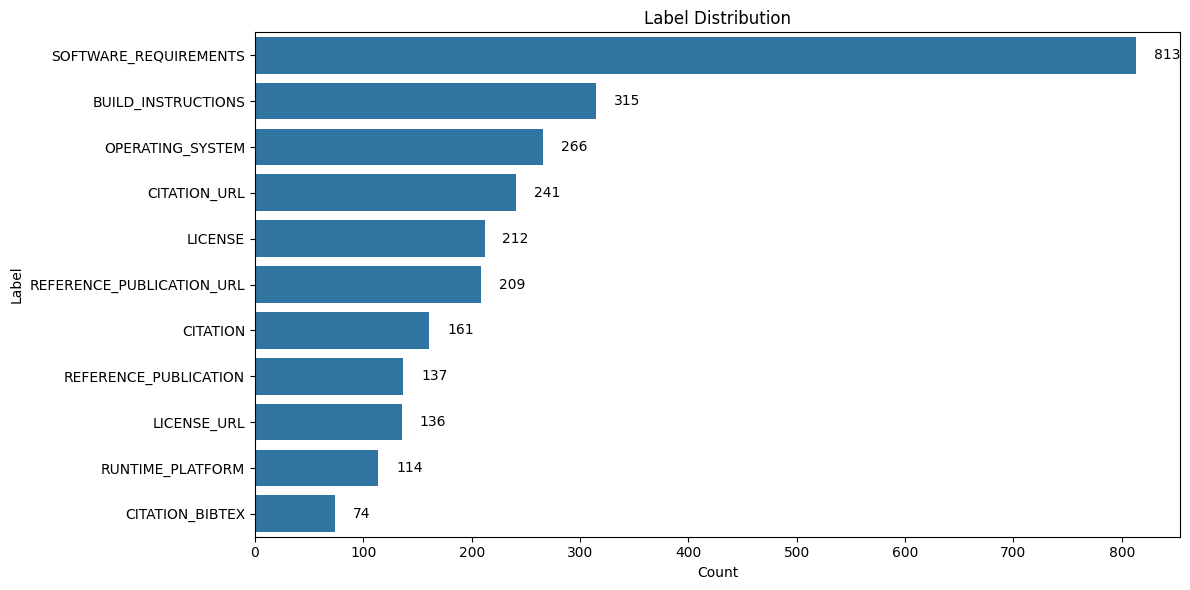

2025-11-11 15:51:55,158 - INFO - Label counts:
                    Label  Count
    SOFTWARE_REQUIREMENTS    813
       BUILD_INSTRUCTIONS    315
         OPERATING_SYSTEM    266
             CITATION_URL    241
                  LICENSE    212
REFERENCE_PUBLICATION_URL    209
                 CITATION    161
    REFERENCE_PUBLICATION    137
              LICENSE_URL    136
         RUNTIME_PLATFORM    114
          CITATION_BIBTEX     74
2025-11-11 15:51:55,161 - INFO - Unique labels: 11
2025-11-11 15:51:55,163 - INFO - Min/Max counts: 74/813 - Imbalance ratio: 10.99


In [7]:
def extract_entities_any(data: List[Dict]) -> Tuple[List[Dict], Dict[str, int]]:
    """Handle both raw (Label Studio) and processed/augmented data."""
    processed_data = []
    label_counts = Counter()

    for task in data:
        if 'data' in task:  # raw format
            text = task['data']['text']
            entities = []
            if 'annotations' in task and task['annotations']:
                for ann in task['annotations'][0].get('result', []):
                    if 'value' in ann:
                        val = ann['value']
                        entities.append({
                            'start': val['start'],
                            'end': val['end'],
                            'label': val['labels'][0],
                            'text': val['text']
                        })
                        label_counts[val['labels'][0]] += 1
        else:  # already processed/augmented format
            text = task['text']
            entities = task.get('entities', [])
            for ent in entities:
                label_counts[ent['label']] += 1

        processed_data.append({'text': text, 'entities': entities})

    return processed_data, dict(label_counts)

_, label_counts_aug = extract_entities_any(augmented_data)

# Visualize label distribution with counts on bars
df_labels = pd.DataFrame(list(label_counts_aug.items()), columns=['Label', 'Count']).sort_values('Count', ascending=False)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Count', y='Label', data=df_labels)
plt.title('Label Distribution')

# Add count labels to each bar
for i, (count, label) in enumerate(zip(df_labels['Count'], df_labels['Label'])):
    ax.text(count + 0.02 * max(df_labels['Count']),
            i,
            str(count),
            va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

logger.info(f"Label counts:\n{df_labels.to_string(index=False)}")
logger.info(f"Unique labels: {len(label_counts_aug)}")
min_count, max_count = df_labels['Count'].min(), df_labels['Count'].max()
logger.info(f"Min/Max counts: {min_count}/{max_count} - Imbalance ratio: {max_count/min_count:.2f}")

In [8]:
# Cell 5: Prepare Label Mapping and IOB Format
# Create unique labels list, including O
all_labels = sorted(set(label_counts.keys()))
label2id = {label: i for i, label in enumerate(all_labels, start=1)}  # 0 for O
id2label = {i: label for label, i in label2id.items()}
label2id['O'] = 0
id2label[0] = 'O'

NUM_LABELS = len(label2id)
logger.info(f"Number of labels: {NUM_LABELS}")
logger.info(f"Label mapping: {label2id}")

2025-11-11 15:51:55,172 - INFO - Number of labels: 12
2025-11-11 15:51:55,175 - INFO - Label mapping: {'BUILD_INSTRUCTIONS': 1, 'CITATION': 2, 'CITATION_BIBTEX': 3, 'CITATION_URL': 4, 'LICENSE': 5, 'LICENSE_URL': 6, 'OPERATING_SYSTEM': 7, 'REFERENCE_PUBLICATION': 8, 'REFERENCE_PUBLICATION_URL': 9, 'RUNTIME_PLATFORM': 10, 'SOFTWARE_REQUIREMENTS': 11, 'O': 0}


In [9]:
# Cell 6: Tokenize and Align Labels
MODEL_NAME = 'roberta-large'  # User's preferred model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, add_prefix_space=True)

def tokenize_and_align_labels(examples: Dict) -> Dict:
    """Tokenize texts and align labels to token level (IOB2 format)."""
    tokenized_inputs = tokenizer(
        examples['text'],
        truncation=True,
        max_length=512,
        is_split_into_words=False,  # Since we have char offsets
        return_offsets_mapping=True
    )

    labels = []
    for i, entities in enumerate(examples['entities']):
        offset_mapping = tokenized_inputs.offset_mapping[i]
        label_ids = [0] * len(offset_mapping)  # Default O

        for ent in entities:
            start_char, end_char = ent['start'], ent['end']
            label = ent['label']

            # Find token indices for entity
            start_token = next((j for j, (s, e) in enumerate(offset_mapping) if s <= start_char < e), None)
            end_token = next((j for j, (s, e) in enumerate(offset_mapping) if s < end_char <= e), None)

            if start_token is not None and end_token is not None:
                label_ids[start_token] = label2id[f"B-{label}"] if f"B-{label}" in label2id else label2id[label]  # Assuming BIO, but adjust if IOB2 needed
                for k in range(start_token + 1, end_token + 1):
                    label_ids[k] = label2id[f"I-{label}"] if f"I-{label}" in label2id else label2id[label]

        labels.append(label_ids)

    tokenized_inputs['labels'] = labels
    return tokenized_inputs

# Update label mapping for BIO if needed
# For simplicity, assuming flat labels (no BIO), as many NER setups do for custom. But for overlapping/best, use BIO.
# To enable BIO: Add B- and I- prefixes
bio_labels = ['O'] + [f"B-{l}" for l in all_labels] + [f"I-{l}" for l in all_labels]
label2id = {l: i for i, l in enumerate(bio_labels)}
id2label = {i: l for l, i in label2id.items()}
NUM_LABELS = len(label2id)
logger.info("Using BIO scheme for labels")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

2025-11-11 15:51:58,558 - INFO - Using BIO scheme for labels


In [10]:
# Cell 7: Create Hugging Face Dataset and Split
# Flatten augmented_data into dict for Dataset
hf_data = {
    'text': [d['text'] for d in augmented_data],
    'entities': [d['entities'] for d in augmented_data]
}

dataset = Dataset.from_dict(hf_data)
tokenized_dataset = dataset.map(tokenize_and_align_labels, batched=True, remove_columns=dataset.column_names)

# Split: 80/10/10
train_test = tokenized_dataset.train_test_split(test_size=0.2, seed=SEED)
val_test = train_test['test'].train_test_split(test_size=0.5, seed=SEED)

datasets = DatasetDict({
    'train': train_test['train'],
    'validation': val_test['train'],
    'test': val_test['test']
})

logger.info(f"Dataset splits: {datasets}")

Map:   0%|          | 0/2346 [00:00<?, ? examples/s]

2025-11-11 15:52:03,135 - INFO - Dataset splits: DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 1876
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 235
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'offset_mapping', 'labels'],
        num_rows: 235
    })
})


In [14]:
# Cell 8: compute_metrics
seqeval = evaluate.load("seqeval")

def compute_metrics(p: EvalPrediction) -> Dict:
    preds = np.argmax(p.predictions, axis=2)
    labels = p.label_ids

    true_predictions, true_labels = [], []
    for pred, lab in zip(preds, labels):
        pred_tags, true_tags = [], []
        for p_i, l_i in zip(pred, lab):
            if l_i != -100:
                pred_tags.append(id2label[p_i])
                true_tags.append(id2label[l_i])
        true_predictions.append(pred_tags)
        true_labels.append(true_tags)

    # seqeval entity-level metrics
    results = seqeval.compute(
        predictions=true_predictions,
        references=true_labels,
        zero_division=0
    )

    # If "per_label" not available, skip safely
    if "per_label" in results:
        entity_metrics = results["per_label"]
        per_class_f1 = [v["f1"] for v in entity_metrics.values() if not np.isnan(v["f1"])]
        macro_f1 = np.mean(per_class_f1)
    else:
        macro_f1 = results["overall_f1"]  # fallback

    # Weighted F1 via sklearn (token-level flatten)
    from sklearn.metrics import precision_recall_fscore_support
    y_true_flat, y_pred_flat = [], []
    for t_seq, p_seq in zip(true_labels, true_predictions):
        y_true_flat.extend(t_seq)
        y_pred_flat.extend(p_seq)

    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_flat, average="weighted", zero_division=0
    )

    return {
        "precision": results["overall_precision"],
        "recall": results["overall_recall"],
        "f1": results["overall_f1"],       # micro/overall F1
        "f1_macro": macro_f1,
        "f1_weighted": f1_weighted,
        "accuracy": results["overall_accuracy"],
    }


In [15]:
# Cell 9: Model and Training Setup
model = AutoModelForTokenClassification.from_pretrained(MODEL_NAME,
                                                        num_labels=NUM_LABELS,
                                                        id2label=id2label,
                                                        label2id=label2id,
                                                        hidden_dropout_prob=0.2,
                                                        attention_probs_dropout_prob=0.2
                                                        )
model.to(device)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=10,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    logging_dir='./logs',
    logging_steps=10,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    gradient_accumulation_steps=2,
    warmup_steps=100,
    lr_scheduler_type="linear",
)

data_collator = DataCollatorForTokenClassification(tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=datasets['train'],
    eval_dataset=datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2,early_stopping_threshold=0.001)]
)

logger.info("Starting training...")

Some weights of RobertaForTokenClassification were not initialized from the model checkpoint at roberta-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-1225626066.py:35: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
2025-11-11 15:56:37,211 - INFO - Starting training...


In [16]:
# Cell 10: Train the Model
train_results = trainer.train()
trainer.save_model('./best_model')
tokenizer.save_pretrained('./best_model')
logger.info("Training completed")

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,F1 Macro,F1 Weighted,Accuracy
1,0.294000,0.160590,0.016037,0.052830,0.024605,0.024605,0.950129,0.949897
2,0.216500,0.104476,0.103550,0.132075,0.116086,0.116086,0.962388,0.967313
3,0.105100,0.126344,0.139108,0.400000,0.206426,0.206426,0.963706,0.957879
4,0.092400,0.117214,0.207455,0.483019,0.290249,0.290249,0.968641,0.963384
5,0.050300,0.103426,0.324706,0.520755,0.400000,0.400000,0.974915,0.971795
6,0.034800,0.108306,0.281493,0.683019,0.398678,0.398678,0.973165,0.968295
7,0.020600,0.091930,0.345528,0.641509,0.449141,0.449141,0.979563,0.978255
8,0.018600,0.094095,0.344902,0.600000,0.438017,0.438017,0.977013,0.975391
9,0.018400,0.106037,0.332090,0.671698,0.444444,0.444444,0.975309,0.972998


2025-11-11 16:27:17,781 - INFO - Training completed


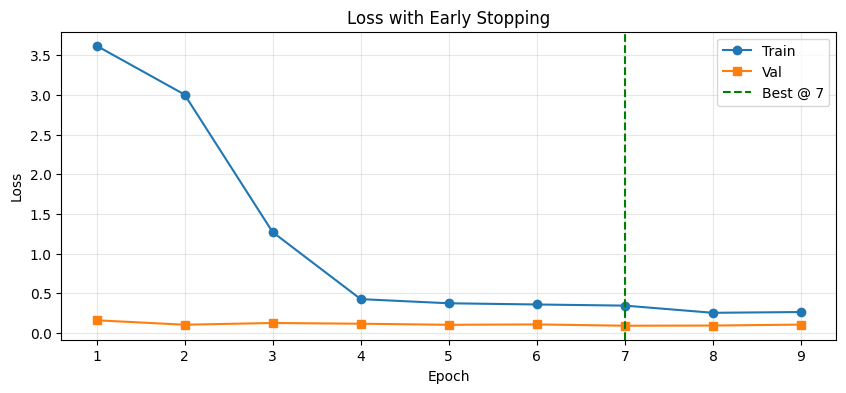

In [17]:
import matplotlib.pyplot as plt

log = trainer.state.log_history
train = [x['loss'] for x in log if 'loss' in x]
val   = [x['eval_loss'] for x in log if 'eval_loss' in x]
epochs = range(1, len(val)+1)

best = min(range(len(val)), key=val.__getitem__) + 1

plt.figure(figsize=(10,4))
plt.plot(epochs, train[:len(val)], label='Train', marker='o')
plt.plot(epochs, val, label='Val', marker='s')
plt.axvline(best, color='green', linestyle='--', label=f'Best @ {best}')
plt.title('Loss with Early Stopping')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

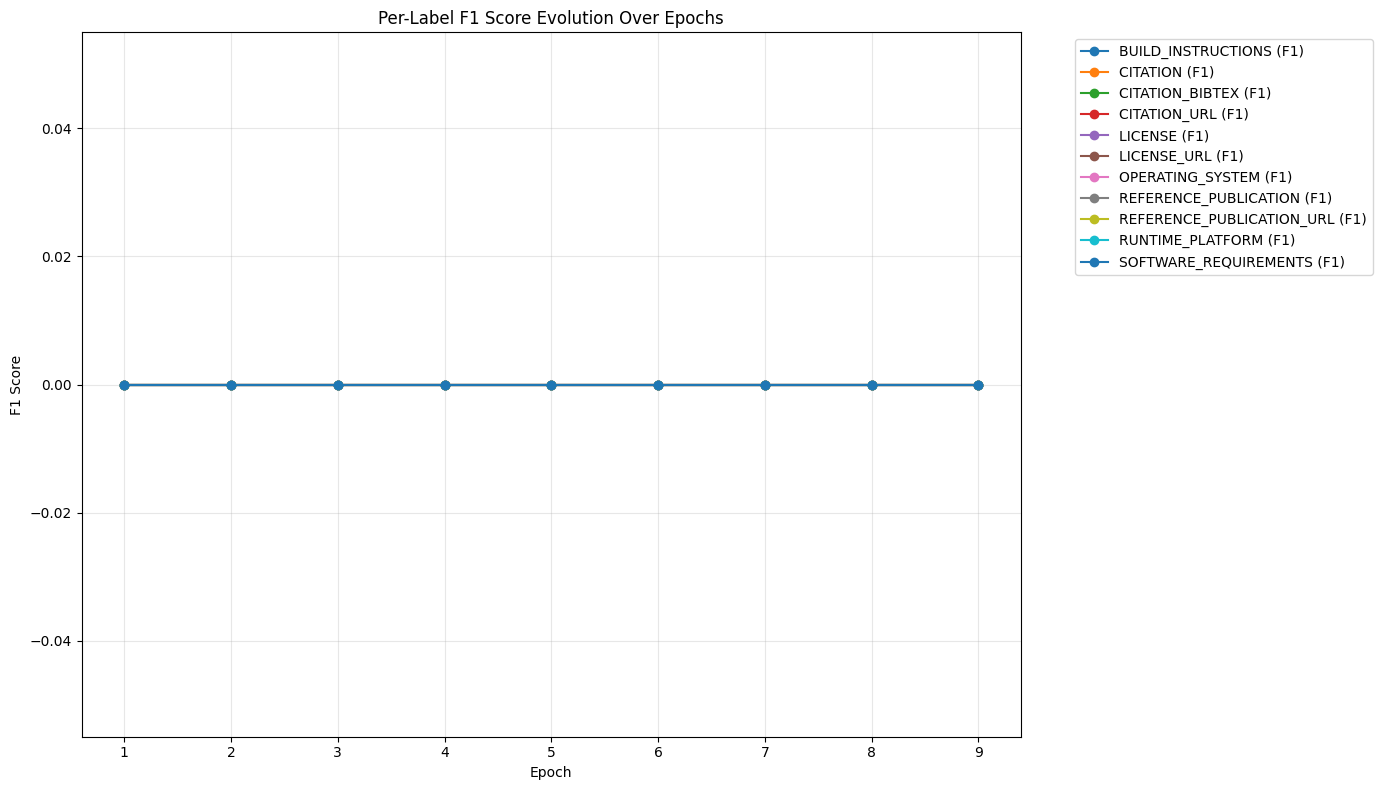

In [18]:
# Cell 12: Plot Per-Label F1 Evolution
per_label_f1_history = defaultdict(list)
epochs = []

for log in trainer.state.log_history:
    if 'eval_f1' in log and 'epoch' in log:
        epoch = int(log['epoch'])
        if epoch not in epochs:
            epochs.append(epoch)
        for label in all_labels:
            key = f"eval_f1_{label}"
            per_label_f1_history[label].append(log.get(key, per_label_f1_history[label][-1] if per_label_f1_history[label] else 0.0))

# Plot
plt.figure(figsize=(14, 8))
for label, f1s in per_label_f1_history.items():
    plt.plot(epochs[:len(f1s)], f1s, label=f"{label} (F1)", marker='o')

plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Per-Label F1 Score Evolution Over Epochs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

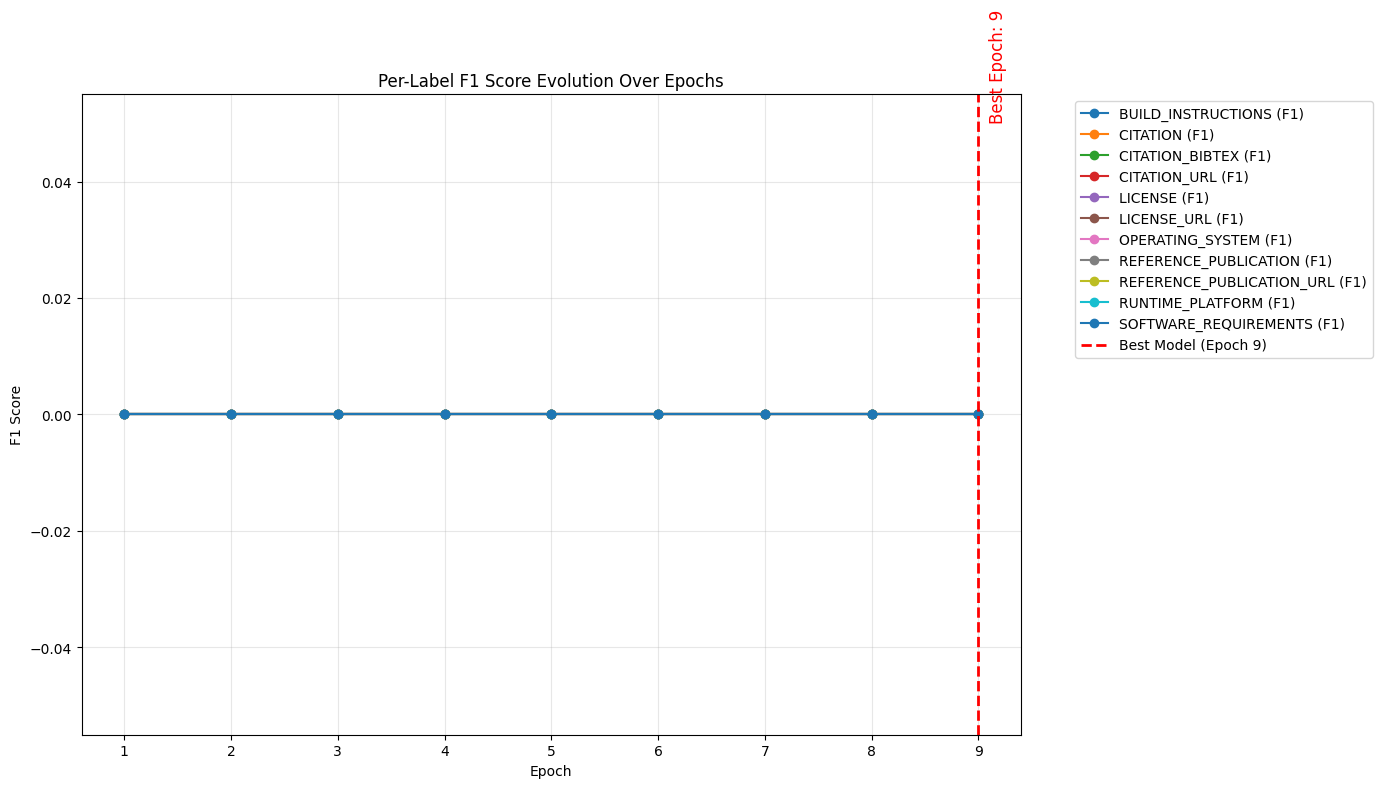

In [19]:
# test one
# Plot
plt.figure(figsize=(14, 8))
for label, f1s in per_label_f1_history.items():
    plt.plot(epochs[:len(f1s)], f1s, label=f"{label} (F1)", marker='o')

# Highlight best epoch
best_epoch = 9  # or compute dynamically as shown above
plt.axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Best Model (Epoch {best_epoch})')
plt.text(best_epoch + 0.1, 0.05, f'Best Epoch: {best_epoch}', color='red', fontsize=12, rotation=90, va='bottom')

plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Per-Label F1 Score Evolution Over Epochs')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
# confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(flat_true, flat_pred, labels=list(label2id.keys()))
cm_df = pd.DataFrame(cm, index=list(label2id.keys()), columns=list(label2id.keys()))

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

NameError: name 'flat_true' is not defined

In [21]:
# Cell 13: Evaluate on Test Set
test_results = trainer.evaluate(datasets['test'])
logger.info(f"Test results: {test_results}")

# Detailed classification report
predictions, labels, _ = trainer.predict(datasets['test'])
predictions = np.argmax(predictions, axis=2)

true_labels = [[id2label[l] for l in label if l != -100] for label in labels]
pred_labels = [[id2label[p] for p, l in zip(pred, label) if l != -100] for pred, label in zip(predictions, labels)]

flat_true = [l for sub in true_labels for l in sub]
flat_pred = [p for sub in pred_labels for p in sub]

print(classification_report(flat_true, flat_pred))

2025-11-11 16:28:01,978 - INFO - Test results: {'eval_loss': 0.18174944818019867, 'eval_precision': 0.302771855010661, 'eval_recall': 0.6425339366515838, 'eval_f1': 0.4115942028985508, 'eval_f1_macro': 0.4115942028985508, 'eval_f1_weighted': 0.9661246215047847, 'eval_accuracy': 0.9643246068737205, 'eval_runtime': 5.8873, 'eval_samples_per_second': 39.916, 'eval_steps_per_second': 5.096, 'epoch': 9.0}
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.ca

                             precision    recall  f1-score   support

       B-BUILD_INSTRUCTIONS       0.48      0.85      0.62        33
                 B-CITATION       0.00      0.00      0.00        14
          B-CITATION_BIBTEX       1.00      0.83      0.91         6
             B-CITATION_URL       0.90      0.96      0.93        28
                  B-LICENSE       0.65      1.00      0.79        15
              B-LICENSE_URL       0.84      1.00      0.91        16
         B-OPERATING_SYSTEM       0.26      0.80      0.39        10
    B-REFERENCE_PUBLICATION       0.00      0.00      0.00        25
B-REFERENCE_PUBLICATION_URL       0.70      0.80      0.74        20
         B-RUNTIME_PLATFORM       0.57      0.67      0.62         6
    B-SOFTWARE_REQUIREMENTS       0.35      0.79      0.48        48
       I-BUILD_INSTRUCTIONS       0.56      0.85      0.68       620
                 I-CITATION       0.81      0.83      0.82       979
          I-CITATION_BIBTEX      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [22]:
# Cell 14: Inference Function with Post-Processing
from transformers import pipeline

ner_pipeline = pipeline('ner', model='./best_model', tokenizer='./best_model', aggregation_strategy='simple', device=0 if torch.cuda.is_available() else -1)

def infer_and_clean(text: str) -> List[Dict]:
    """Infer entities and apply post-cleaning: merge adjacent same-label, remove short/incomplete, validate patterns."""
    results = ner_pipeline(text)

    # Merge adjacent entities of same label
    merged = []
    for ent in results:
        if merged and merged[-1]['entity_group'] == ent['entity_group'] and merged[-1]['end'] == ent['start']:
            merged[-1]['word'] += ent['word']
            merged[-1]['end'] = ent['end']
            merged[-1]['score'] = (merged[-1]['score'] + ent['score']) / 2
        else:
            merged.append(ent)

    # High post-cleaning: Remove low-confidence (<0.7), short (<3 chars), or invalid patterns
    cleaned = []
    for ent in merged:
        if ent['score'] < 0.7 or len(ent['word']) < 3:
            continue
        # Label-specific cleaning, e.g., for URLs
        if 'URL' in ent['entity_group']:
            if not re.match(r'https?://', ent['word']):
                continue
        # For citations, ensure looks like ref
        if 'CITATION' in ent['entity_group'] and not re.search(r'\d{4}', ent['word']):
            continue
        cleaned.append(ent)

    return cleaned

# Test on sample
sample_text = raw_data[2]['data']['text'][:1000]  # Truncate for test
extracted = infer_and_clean(sample_text)
logger.info(f"Extracted entities: {extracted}")

Device set to use cuda:0
2025-11-11 16:28:56,508 - INFO - Extracted entities: [{'entity_group': 'RUNTIME_PLATFORM', 'score': np.float32(0.94900596), 'word': 'Node.js (version 12 or higher)', 'start': 693, 'end': 723}, {'entity_group': 'SOFTWARE_REQUIREMENTS', 'score': np.float32(0.783702), 'word': 'npm (Node Package Manager)', 'start': 725, 'end': 751}, {'entity_group': 'SOFTWARE_REQUIREMENTS', 'score': np.float32(0.8799293), 'word': 'TypeScript', 'start': 753, 'end': 763}]


In [23]:
#!zip -r /content/model.zip /content/best_model/

  adding: content/best_model/ (stored 0%)
  adding: content/best_model/config.json (deflated 65%)
  adding: content/best_model/model.safetensors (deflated 9%)
  adding: content/best_model/training_args.bin (deflated 53%)
  adding: content/best_model/vocab.json (deflated 59%)
  adding: content/best_model/special_tokens_map.json (deflated 52%)
  adding: content/best_model/tokenizer_config.json (deflated 75%)
  adding: content/best_model/merges.txt (deflated 53%)
  adding: content/best_model/tokenizer.json (deflated 82%)


In [24]:
from google.colab import files
#files.download('/content/model.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>